# Exploratory Data Analysis — M2OR receptor–ligand pairs

**Dataset.** `m2or_pairs.csv` — the *Molecule-to-Olfactory-Receptor* (**M2OR**) database:
one row per **(olfactory receptor, molecule)** experiment, labelled with whether the
receptor **responded** to the molecule.

**Goal of this notebook.** Get a first, honest picture of the data before any modelling:
what the columns mean, how complete they are, the class balance of the `Responsive`
label, which receptors / molecules / species dominate, and the chemical space of the
ligands. Findings are collected at the end.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

print("Python :", sys.version.split()[0])
print("pandas :", pd.__version__)
print("numpy  :", np.__version__)

# --- plotting conventions for this repo -------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams["figure.dpi"] = 300
mpl.rcParams["savefig.bbox"] = "tight"
mpl.rcParams["svg.fonttype"] = "none"   # keep text as text in SVG
FIGSIZE = (4, 3)                         # repo default

FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

def savefig(fig, name):
    """Export a figure as both SVG and PNG into ./figures (repo convention)."""
    for ext in ("svg", "png"):
        fig.savefig(FIGDIR / f"{name}.{ext}", dpi=300, bbox_inches="tight")
    return fig


Python : 3.10.13
pandas : 2.2.3
numpy  : 2.1.3


## 1. Load & first look

The file is **semicolon-separated** and carries a UTF-8 BOM, so we read it explicitly.

In [2]:
df = pd.read_csv("m2or_pairs.csv", sep=";")
print("rows x cols:", df.shape)
df


rows x cols: (53444, 14)


,Species,Gene Name,UniProt ID,Mutation,Sequence,Molecule Name,CID,CAS,InChIKey,SMILES,Mixture,Responsive,Data Quality,Number of Unique Value Screen
0,homo sapiens,OR10S1,Q8NGN2,NaN,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,(-)-limonene,439250.0,5989-54-8,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C,mono,0,primaryScreening,1.0
1,homo sapiens,OR10S1,Q8NGN2,NaN,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,(+)-carvone,16724.0,6485-40-1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C,mono,0,secondaryScreening,2.0
2,homo sapiens,OR10S1,Q8NGN2,NaN,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,(+)-menthol,165675.0,2216-51-5,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mono,0,primaryScreening,1.0
3,homo sapiens,OR10S1,Q8NGN2,NaN,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,1-butanol,263.0,71-36-3,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO,mono,0,primaryScreening,1.0
4,homo sapiens,OR10S1,Q8NGN2,NaN,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,1-butoxy-2-propanol,21210.0,5131-66-8,RWNUSVWFHDHRCJ-UHFFFAOYSA-N,CCCCOCC(C)O,sum of isomers,0,primaryScreening,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53439,homo sapiens,OR51F1_OR51F1P,A6NGY5,NaN,MLQNQDTMEILSNSTSKFPTFLLTGIPGLESAHVWISIPFCCFYAI...,N-hexanal,6184.0,66-25-1,JARKCYVAAOWBJS-UHFFFAOYSA-N,CCCCCC=O,mono,0,primaryScreening,1.0
53440,homo sapiens,OR51T1,Q8NGJ9,NaN,MAIFNNTTSSSSNFLLTAFPGLECAHVWISIPVCCLYTIALLGNSM...,N-hexanal,6184.0,66-25-1,JARKCYVAAOWBJS-UHFFFAOYSA-N,CCCCCC=O,mono,0,primaryScreening,1.0
53441,homo sapiens,OR52E5,Q8NH55,NaN,MLHTNNTQFHPSTFLVVGVPGLEDVHVWIGFPFFAVYLTALLGNII...,N-hexanal,6184.0,66-25-1,JARKCYVAAOWBJS-UHFFFAOYSA-N,CCCCCC=O,mono,0,primaryScreening,1.0
53442,homo sapiens,OR52L1,Q8NGH7,NaN,MTLVSFFSFLSKPLIMLLSNSSWRLSQPSFLLVGIPGLEESQHWIA...,N-hexanal,6184.0,66-25-1,JARKCYVAAOWBJS-UHFFFAOYSA-N,CCCCCC=O,mono,0,primaryScreening,1.0


In [3]:
df[df["Molecule Name"] == "Bradykinin"]

,Species,Gene Name,UniProt ID,Mutation,Sequence,Molecule Name,CID,CAS,InChIKey,SMILES,Mixture,Responsive,Data Quality,Number of Unique Value Screen
47940,homo sapiens,OR51E2,Q9H255,NaN,MSSCNFTHATFVLIGIPGLEKAHFWVGFPLLSMYVVAMFGNCIVVF...,Bradykinin,439201.0,58-82-2,QXZGBUJJYSLZLT-FDISYFBBSA-N,C1C[C@H](N(C1)C(=O)[C@@H]2CCCN2C(=O)[C@H](CCCN...,mono,1,ec50,NaN


In [3]:
# Compact column dictionary: type, unique values, missingness
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
})
overview


,dtype,n_unique,n_missing,pct_missing
Species,object,16,0,0.0
Gene Name,object,563,0,0.0
UniProt ID,object,598,0,0.0
Mutation,object,802,36432,68.2
Sequence,object,1402,0,0.0
Molecule Name,object,1223,0,0.0
CID,float64,753,1656,3.1
CAS,object,381,23403,43.8
InChIKey,object,770,387,0.7
SMILES,object,771,0,0.0


**Column meanings**

| column | meaning |
|---|---|
| `Species`, `Gene Name`, `UniProt ID` | the olfactory receptor tested |
| `Mutation`, `Sequence` | receptor variant / its amino-acid sequence |
| `Molecule Name`, `CID`, `CAS`, `InChIKey`, `SMILES` | the ligand (odorant) |
| `Mixture` | whether the stimulus is a single compound, sum-of-isomers, or a mixture |
| `Responsive` | **label**: 1 = receptor activated by the molecule, 0 = not |
| `Data Quality` | assay type: primary / secondary screening or dose-response (`ec50`) |
| `Number of Unique Value Screen` | # independent measurements aggregated into the row |


## 2. Missingness overview

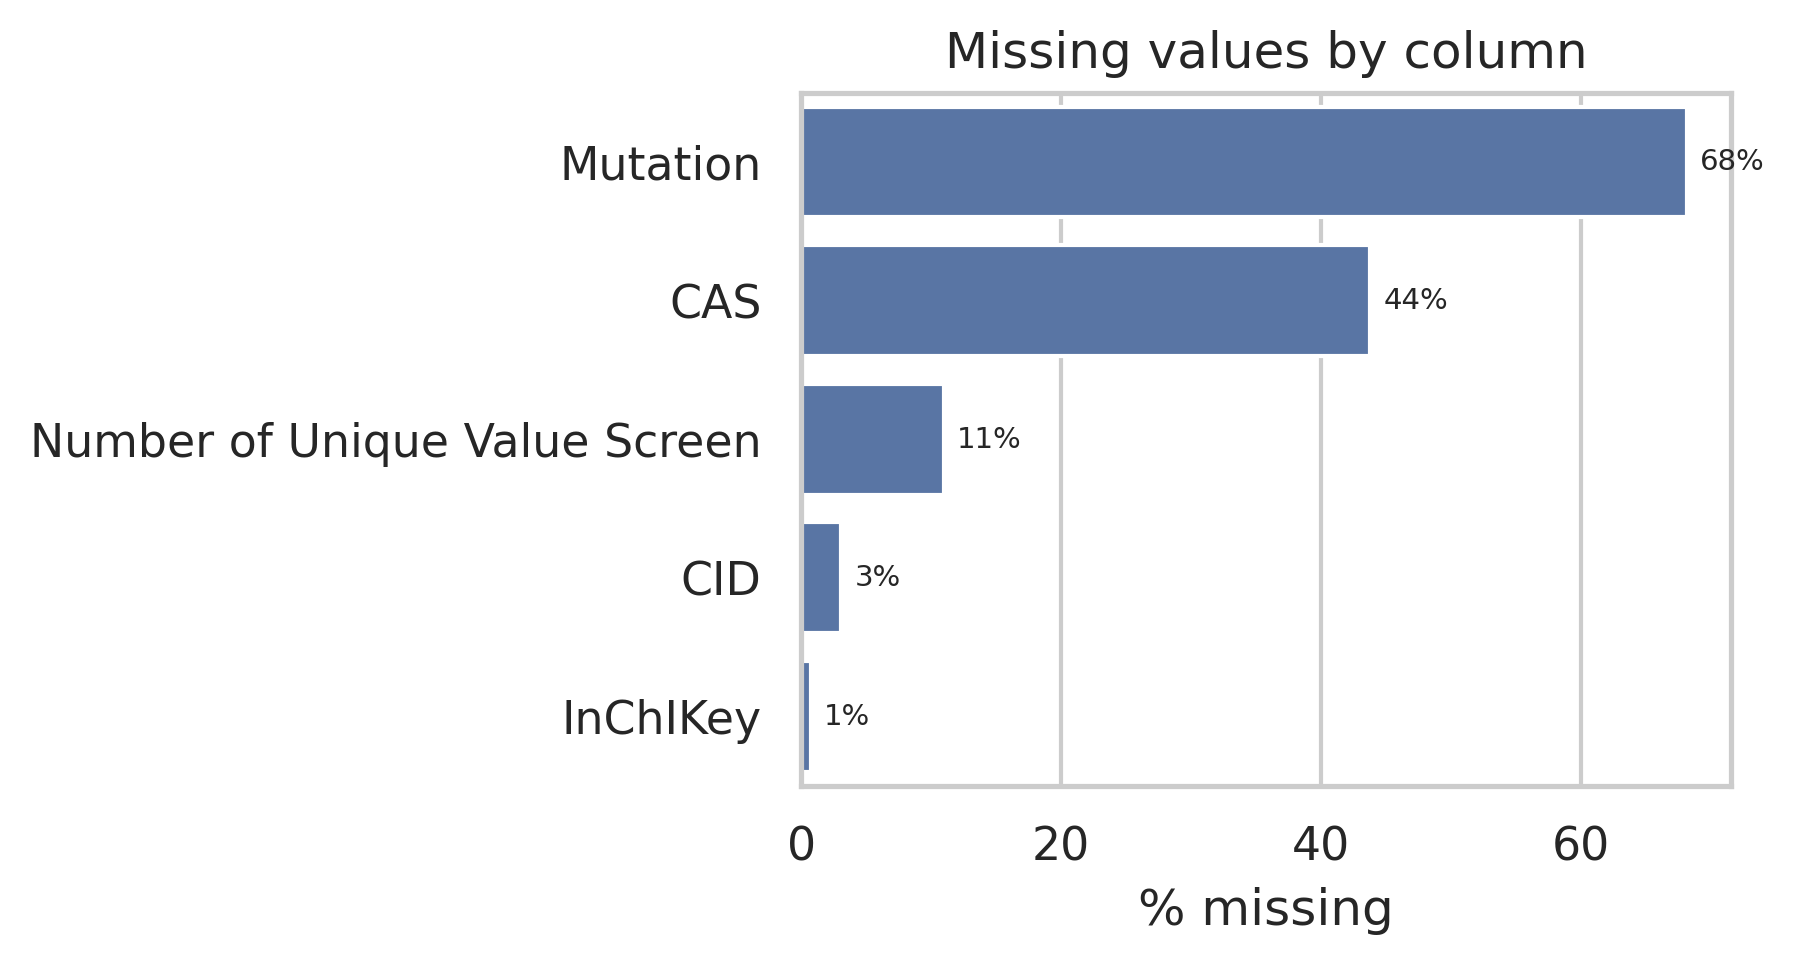

In [4]:
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(x=miss.values, y=miss.index, color="#4C72B0", ax=ax)
ax.set_xlabel("% missing")
ax.set_ylabel("")
ax.set_title("Missing values by column")
for i, v in enumerate(miss.values):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=7)
savefig(fig, "01_missingness")
plt.show()


`Mutation` and `CAS` are mostly empty by design — a blank `Mutation` simply means
**wild-type** receptor, and `CAS` is an optional identifier. The essentials
(`SMILES`, `Sequence`, `Responsive`, `Species`) are complete.

## 3. The label: `Responsive`

This is what any classifier would predict — check the balance first.

Responsive
0    50320
1     3124
Name: count, dtype: int64

Positive (hit) rate: 5.85%


/tmp/ipykernel_219801/2163253630.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["0 (no response)", "1 (response)"], y=resp.values,


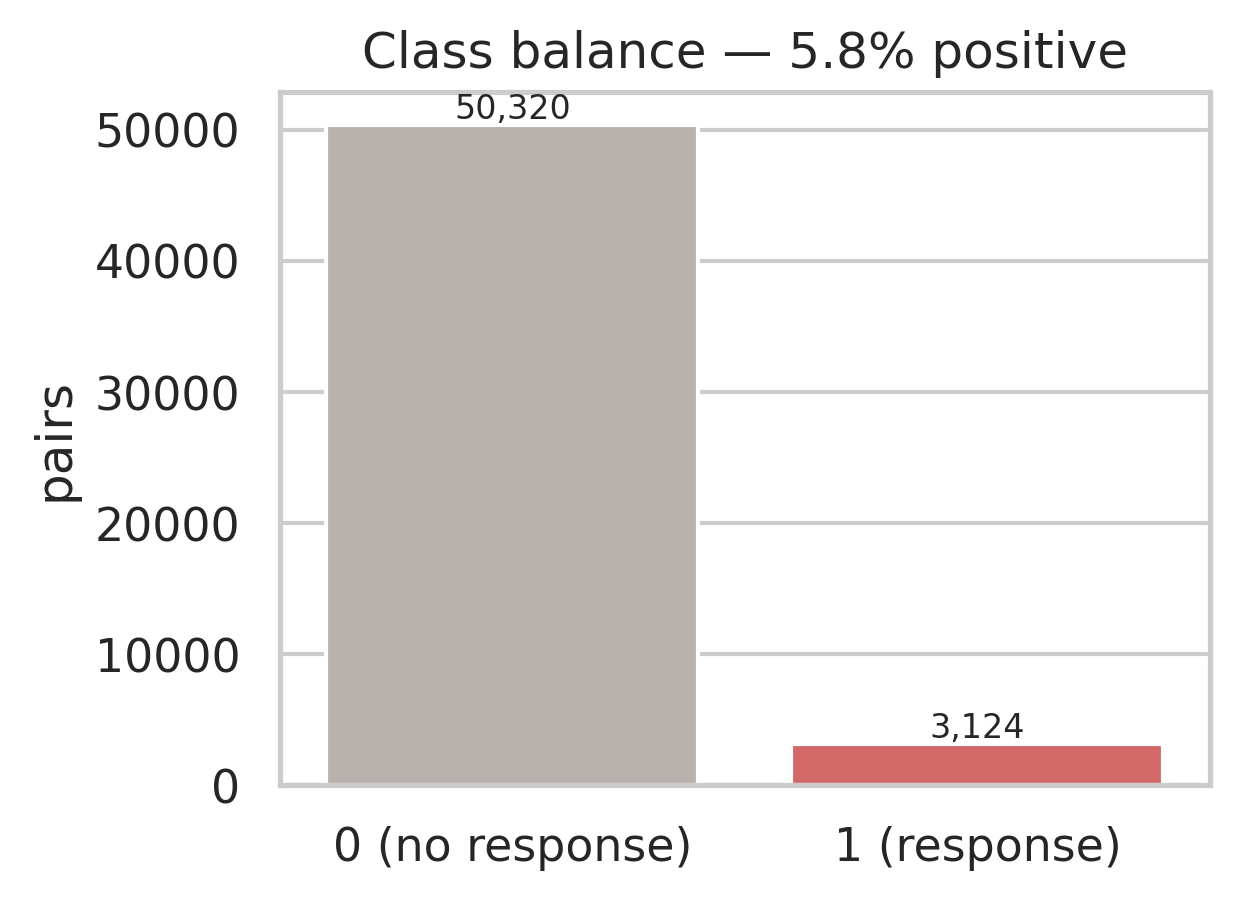

In [5]:
resp = df["Responsive"].value_counts().sort_index()
rate = df["Responsive"].mean()
print(resp)
print(f"\nPositive (hit) rate: {rate:.2%}")

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(x=["0 (no response)", "1 (response)"], y=resp.values,
            palette=["#BAB0AC", "#E45756"], ax=ax)
for i, v in enumerate(resp.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("pairs")
ax.set_title(f"Class balance — {rate:.1%} positive")
savefig(fig, "02_class_balance")
plt.show()


> **Strong class imbalance:** only ~6% of tested pairs are hits. Any modelling must
> account for this (stratified splits, class weights / resampling, PR-AUC over accuracy).

## 4. Species coverage

Species
homo sapiens              42917
mus musculus              10243
pan troglodytes              58
pongo abelii                 51
bos taurus                   41
pan paniscus                 26
ovis aries                   25
canis lupus familiaris       25
puma concolor                25
vulpes vulpes                25
rattus norvegicus             3
dipodomys ordii               1
macaca mulatta                1
ursus maritimus               1
camelus ferus                 1
equus caballus                1
Name: count, dtype: int64


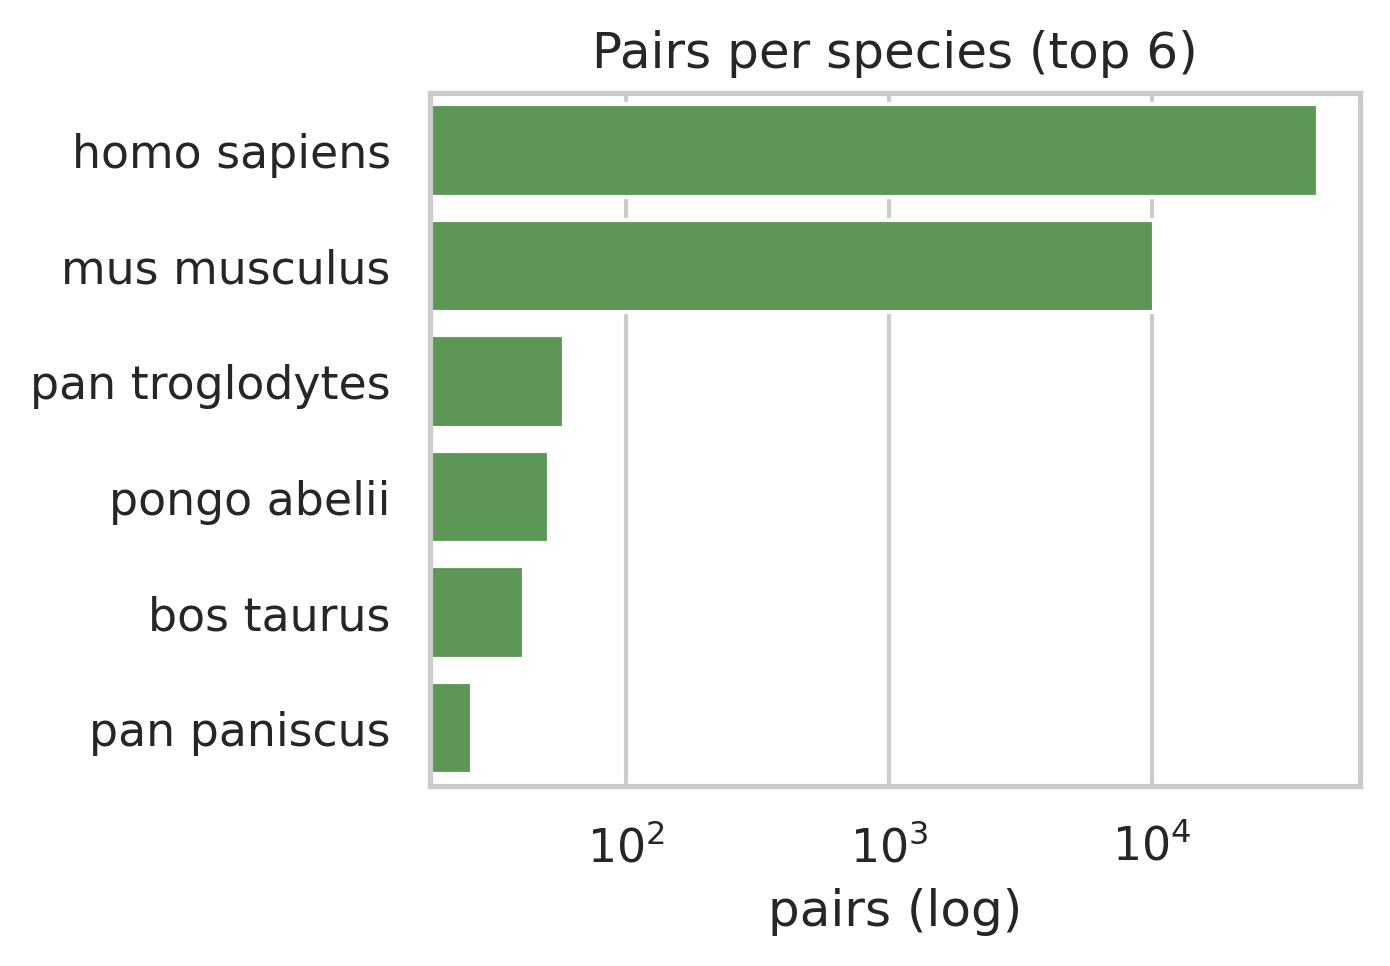

In [6]:
sp = df["Species"].value_counts()
print(sp)

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(x=sp.head(6).values, y=sp.head(6).index, color="#54A24B", ax=ax)
ax.set_xscale("log")
ax.set_xlabel("pairs (log)")
ax.set_ylabel("")
ax.set_title("Pairs per species (top 6)")
savefig(fig, "03_species")
plt.show()


In [7]:
# Hit rate per species (only where there is a reasonable sample)
sp_stats = (df.groupby("Species")["Responsive"]
              .agg(n="count", hit_rate="mean")
              .query("n >= 50")
              .sort_values("n", ascending=False))
sp_stats["hit_rate"] = (sp_stats["hit_rate"] * 100).round(1)
sp_stats


,n,hit_rate
Species,,
homo sapiens,42917,5.4
mus musculus,10243,5.8
pan troglodytes,58,81.0
pongo abelii,51,51.0


The data is dominated by **human** (*homo sapiens*) and **mouse** (*mus musculus*)
receptors; other species contribute only a handful of pairs.

## 5. Receptors

How many distinct receptors, and how unevenly are experiments distributed across them?

In [8]:
n_receptors = df["UniProt ID"].nunique()
n_genes = df["Gene Name"].nunique()
print(f"Unique receptors (UniProt): {n_receptors}")
print(f"Unique gene names        : {n_genes}")

per_receptor = df.groupby("Gene Name").agg(
    n_tests=("Responsive", "size"),
    n_hits=("Responsive", "sum"),
)
per_receptor["hit_rate"] = per_receptor["n_hits"] / per_receptor["n_tests"]

print("\nTests per receptor — distribution:")
print(per_receptor["n_tests"].describe().round(1))


Unique receptors (UniProt): 598
Unique gene names        : 563

Tests per receptor — distribution:
count    563.0
mean      94.9
std       61.1
min        1.0
25%       63.0
50%       89.0
75%      109.5
max      564.0
Name: n_tests, dtype: float64


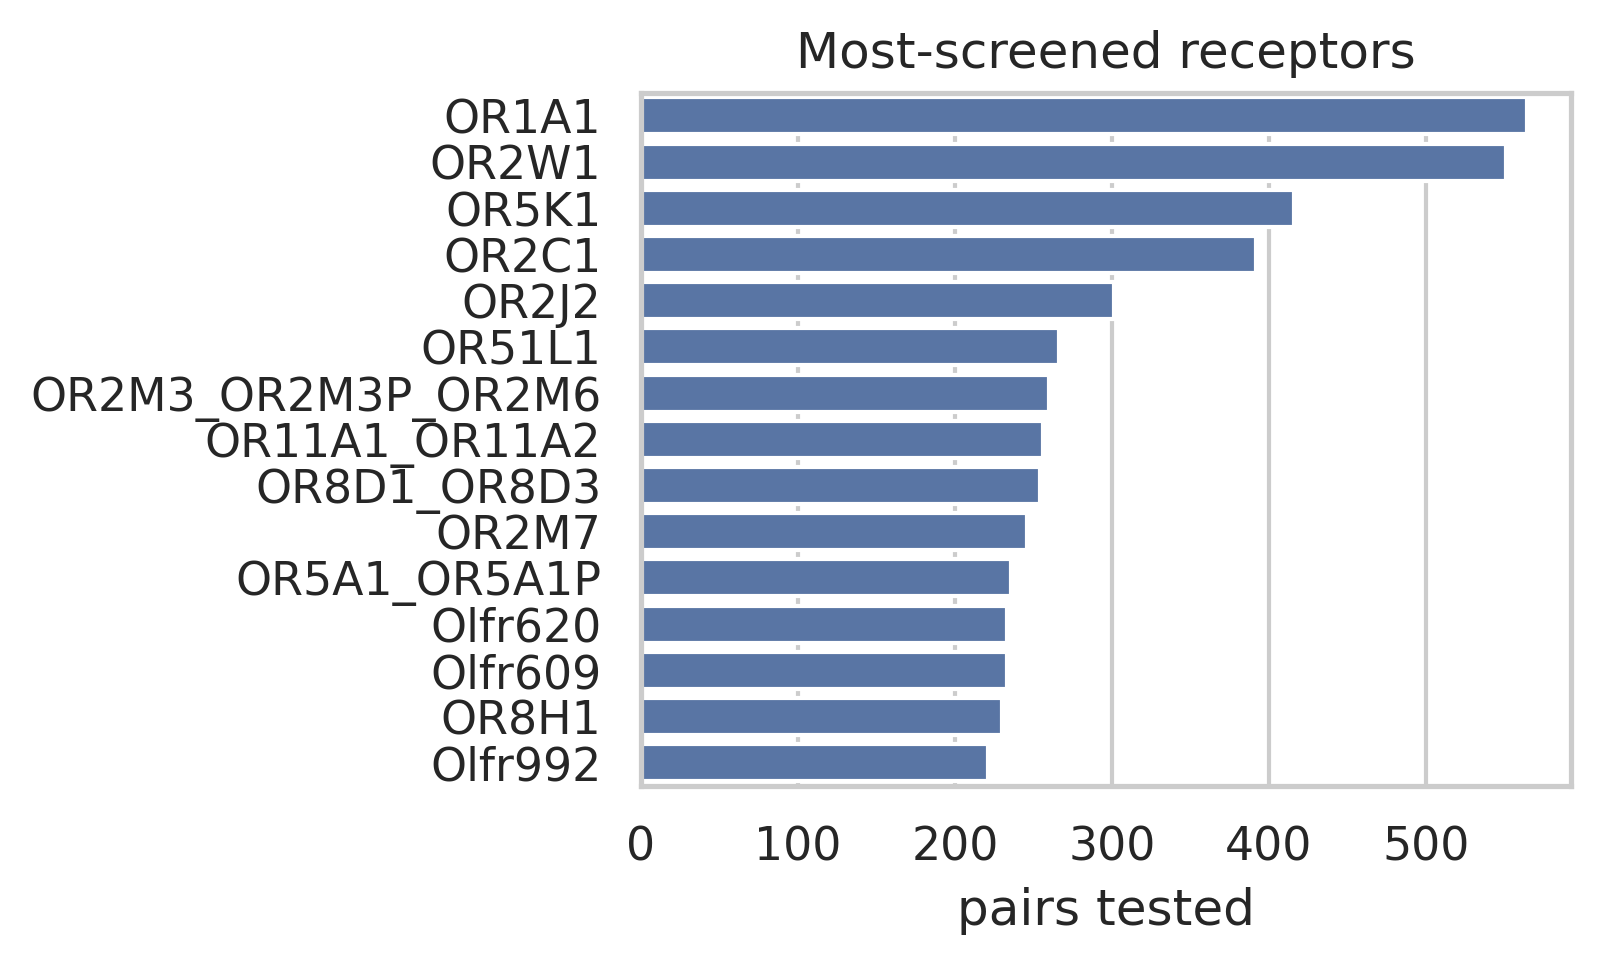

In [9]:
top_tested = per_receptor.sort_values("n_tests", ascending=False).head(15)

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(x=top_tested["n_tests"], y=top_tested.index, color="#4C72B0", ax=ax)
ax.set_xlabel("pairs tested")
ax.set_ylabel("")
ax.set_title("Most-screened receptors")
savefig(fig, "04_top_receptors")
plt.show()


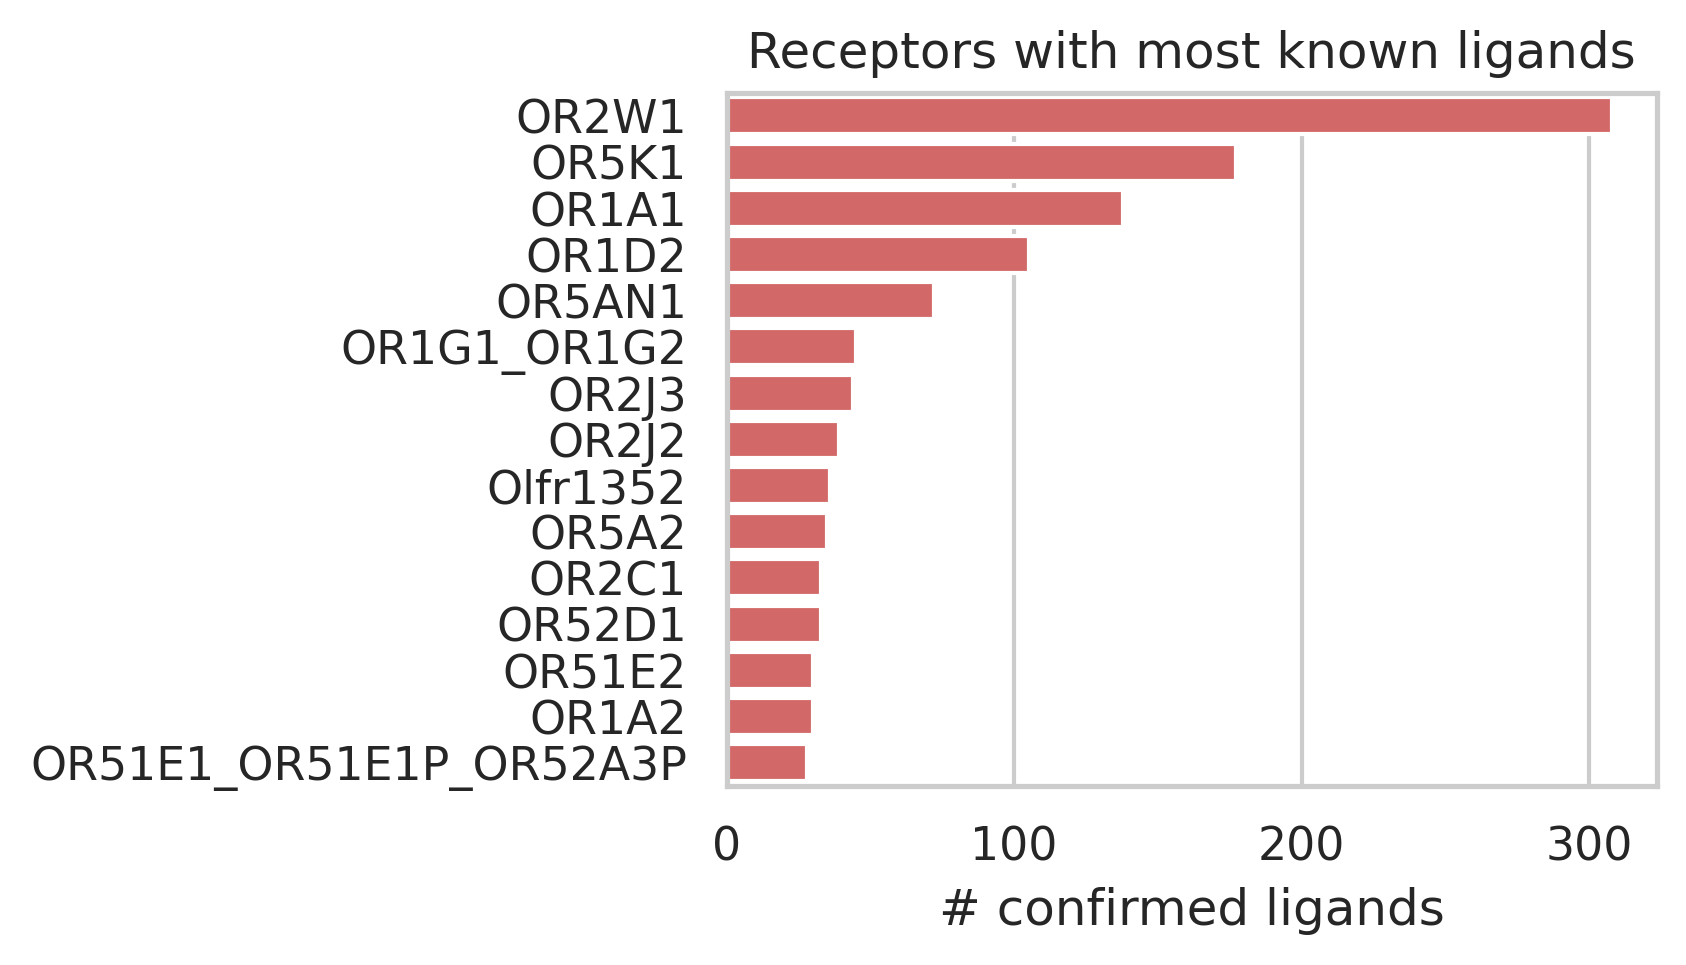

In [10]:
# Receptors ranked by number of confirmed ligands (hits)
top_hits = (per_receptor[per_receptor["n_hits"] > 0]
            .sort_values("n_hits", ascending=False).head(15))
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(x=top_hits["n_hits"], y=top_hits.index, color="#E45756", ax=ax)
ax.set_xlabel("# confirmed ligands")
ax.set_ylabel("")
ax.set_title("Receptors with most known ligands")
savefig(fig, "05_top_receptor_hits")
plt.show()


## 6. Molecules (ligands)

Same question from the chemistry side.

Unique SMILES        : 771
Unique molecule names: 1223


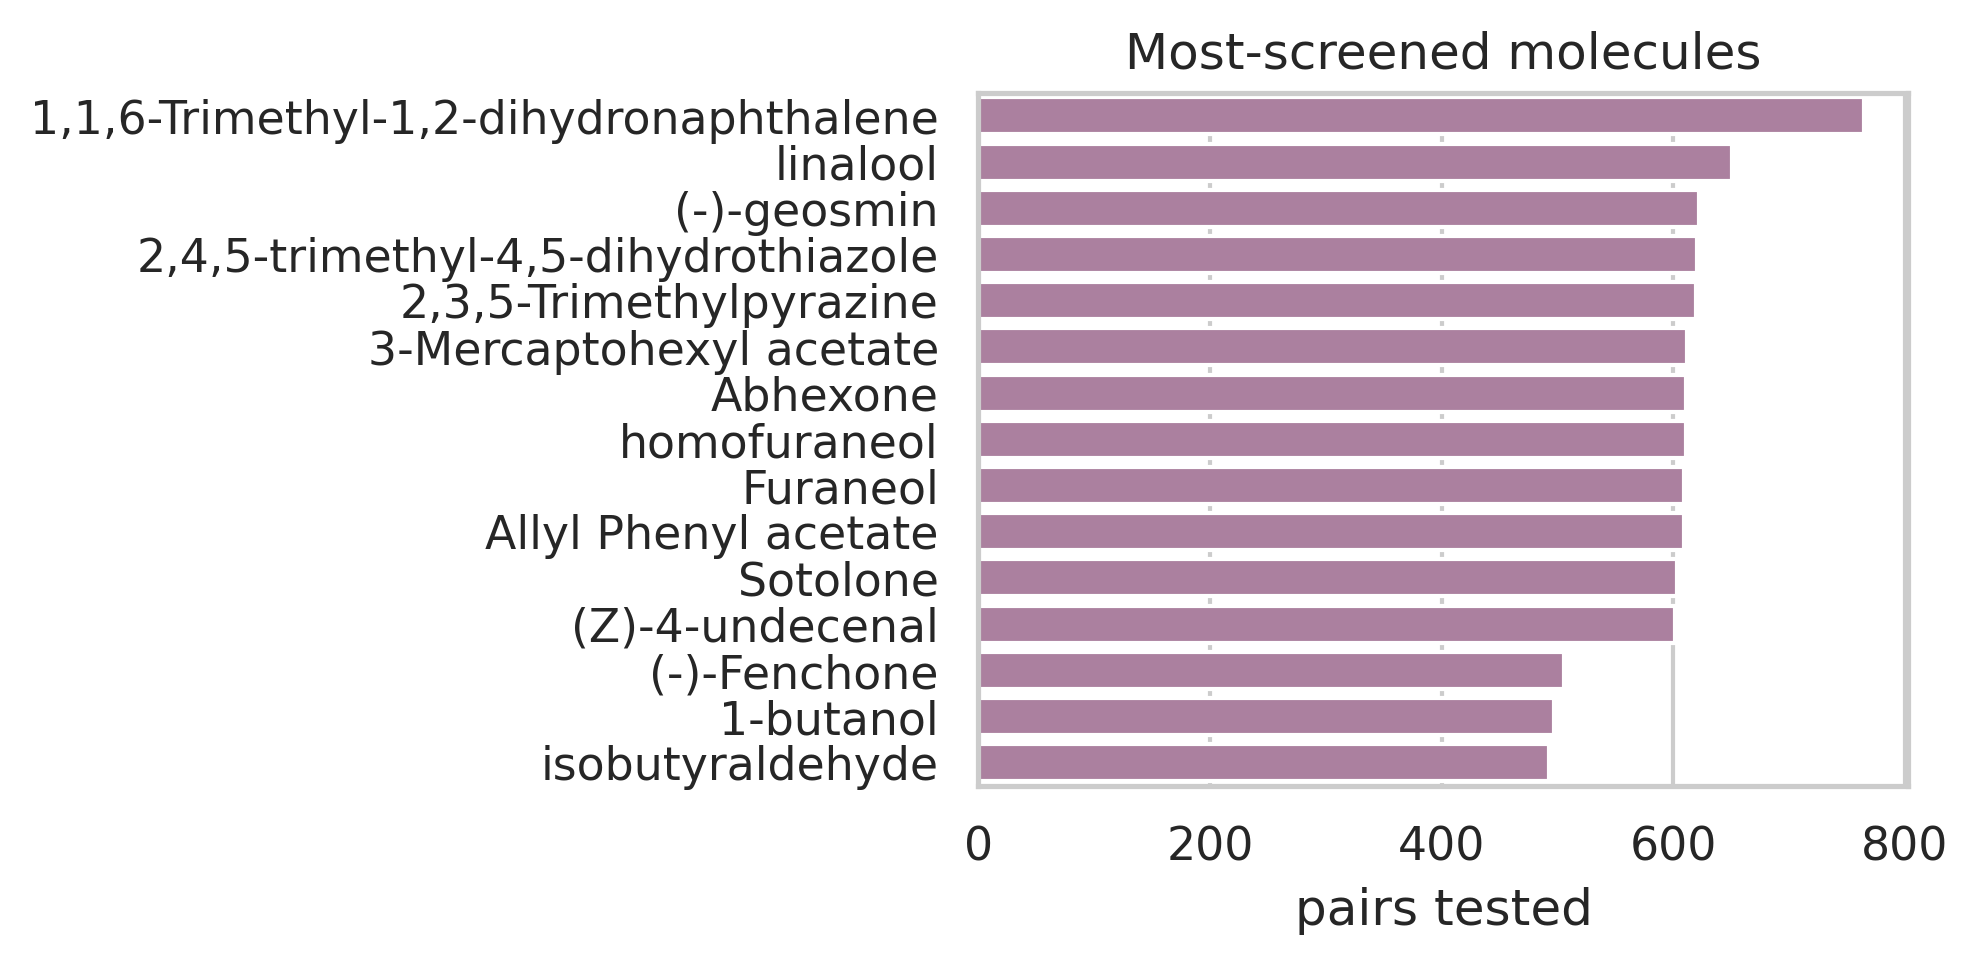

In [11]:
n_smiles = df["SMILES"].nunique()
n_names = df["Molecule Name"].nunique()
print(f"Unique SMILES        : {n_smiles}")
print(f"Unique molecule names: {n_names}")

per_mol = df.groupby("Molecule Name").agg(
    n_tests=("Responsive", "size"),
    n_hits=("Responsive", "sum"),
)
top_mol = per_mol.sort_values("n_tests", ascending=False).head(15)

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(x=top_mol["n_tests"], y=top_mol.index, color="#B279A2", ax=ax)
ax.set_xlabel("pairs tested")
ax.set_ylabel("")
ax.set_title("Most-screened molecules")
savefig(fig, "06_top_molecules")
plt.show()


## 7. Assay metadata: mixture type & data quality

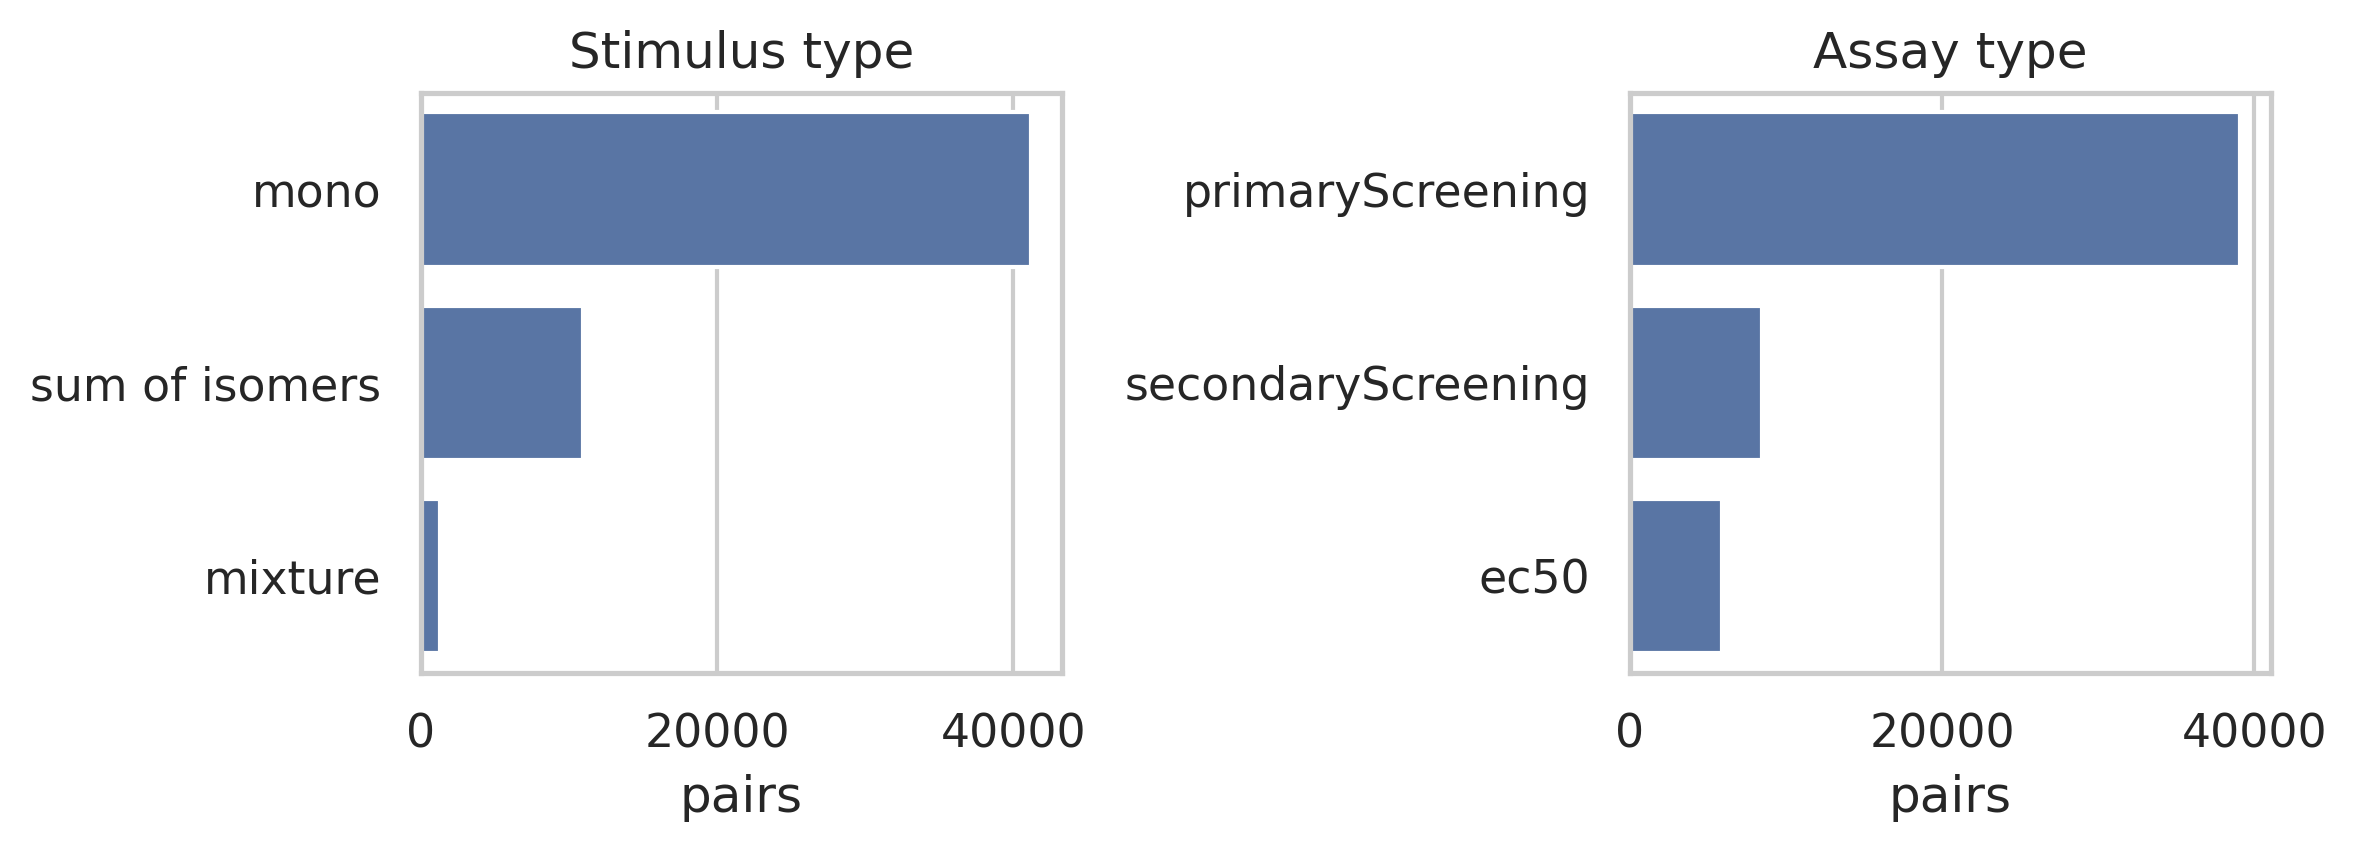

                        n  hit_rate
Data Quality                       
ec50                 5872  0.249319
primaryScreening    39094  0.034762
secondaryScreening   8478  0.035504


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for ax, col, title in [(axes[0], "Mixture", "Stimulus type"),
                       (axes[1], "Data Quality", "Assay type")]:
    vc = df[col].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=ax, color="#4C72B0")
    ax.set_title(title)
    ax.set_xlabel("pairs")
    ax.set_ylabel("")

fig.tight_layout()
savefig(fig, "07_assay_metadata")
plt.show()

# Hit rate by data-quality tier (ec50 rows are dose-response confirmed)
print(df.groupby("Data Quality")["Responsive"].agg(n="count", hit_rate="mean"))


`ec50` rows come from dose-response experiments and, as expected, have a far higher
hit rate than primary screening — they are the confirmed activations.

## 8. Wild-type vs. mutant receptors

In [13]:
df["is_mutant"] = df["Mutation"].notna()
mut = df["is_mutant"].value_counts()
print("Wild-type vs mutant rows:")
print(mut.rename({False: "wild-type", True: "mutant"}))
print("\nHit rate:")
print(df.groupby("is_mutant")["Responsive"].mean().rename(
    {False: "wild-type", True: "mutant"}))


Wild-type vs mutant rows:
is_mutant
wild-type    36432
mutant       17012
Name: count, dtype: int64

Hit rate:
is_mutant
wild-type    0.051768
mutant       0.072772
Name: Responsive, dtype: float64


## 9. Receptor sequence length

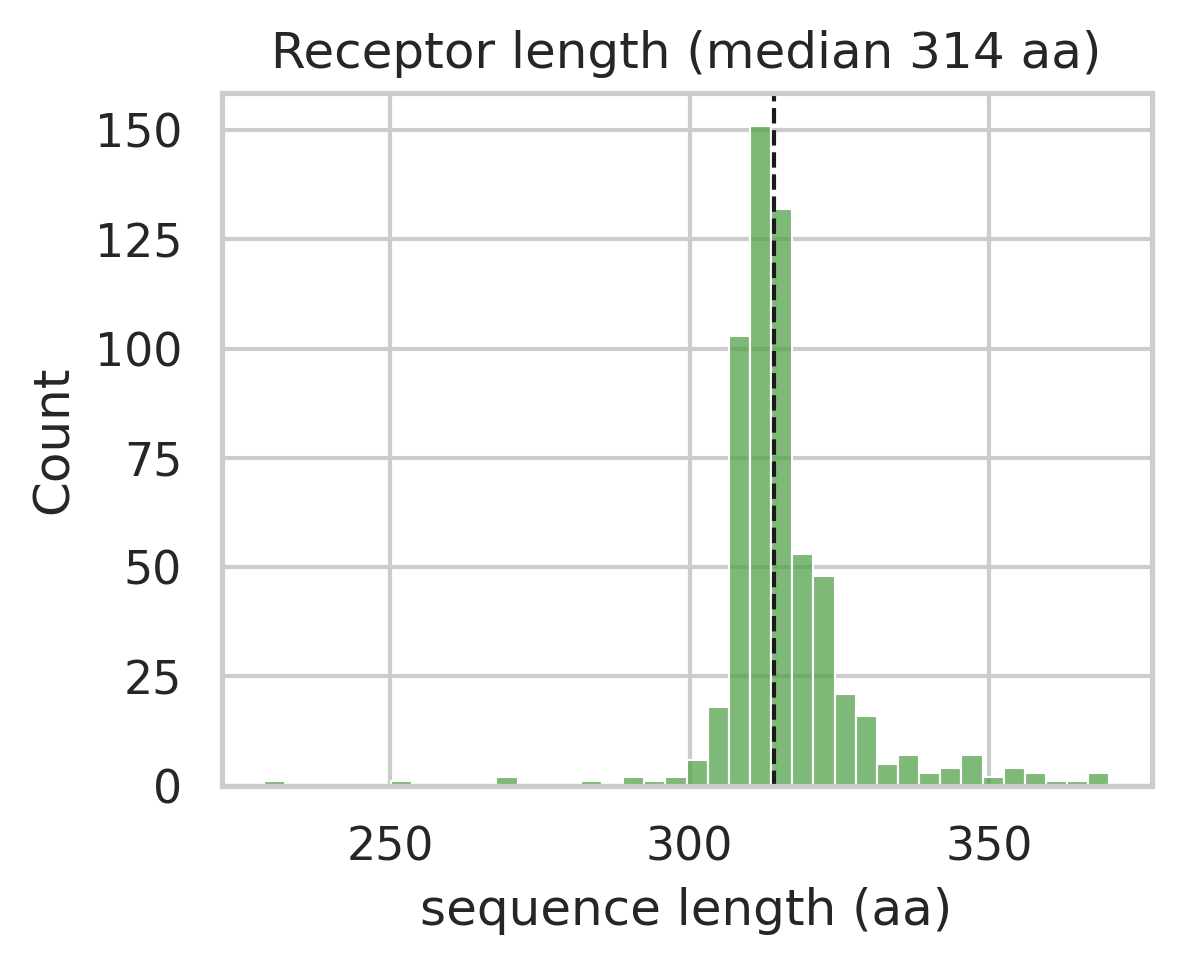

count    598.0
mean     316.0
std       11.6
min      229.0
25%      311.0
50%      314.0
75%      319.0
max      370.0
Name: Sequence, dtype: float64


In [14]:
seq_len = df.drop_duplicates("UniProt ID")["Sequence"].str.len()

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.histplot(seq_len, bins=40, color="#54A24B", ax=ax)
ax.axvline(seq_len.median(), color="k", ls="--", lw=1)
ax.set_xlabel("sequence length (aa)")
ax.set_title(f"Receptor length (median {seq_len.median():.0f} aa)")
savefig(fig, "08_seq_length")
plt.show()
print(seq_len.describe().round(1))


Lengths cluster around ~310–320 aa — the canonical size of a 7-transmembrane
olfactory GPCR — confirming the sequences are sane.

## 10. Chemical space of the ligands

Using **RDKit** we compute a few physicochemical descriptors for each *unique* molecule
and compare the distributions of molecular weight and lipophilicity (LogP), which broadly
characterise the odorant chemical space.

In [15]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")   # silence parse warnings

# One row per unique molecule (mono / sum-of-isomers only — real single structures)
mols = (df[df["Mixture"] != "mixture"]
        .dropna(subset=["SMILES"])
        .drop_duplicates("SMILES")[["Molecule Name", "SMILES"]]
        .copy())

def descriptors(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return pd.Series({"MW": np.nan, "LogP": np.nan, "HBD": np.nan,
                          "HBA": np.nan, "n_heavy": np.nan})
    return pd.Series({
        "MW": Descriptors.MolWt(m),
        "LogP": Crippen.MolLogP(m),
        "HBD": Descriptors.NumHDonors(m),
        "HBA": Descriptors.NumHAcceptors(m),
        "n_heavy": m.GetNumHeavyAtoms(),
    })

desc = mols.join(mols["SMILES"].apply(descriptors))
n_bad = desc["MW"].isna().sum()
print(f"Unique molecules: {len(desc)}  |  unparseable SMILES: {n_bad}")
desc.dropna().describe().round(2)


Unique molecules: 754  |  unparseable SMILES: 0


,MW,LogP,HBD,HBA,n_heavy
count,754.00,754.00,754.00,754.00,754.00
mean,163.17,2.34,0.51,1.67,11.44
std,61.77,1.41,0.94,1.16,4.49
min,44.05,-5.55,0.00,0.00,2.00
25%,130.19,1.54,0.00,1.00,9.00
50%,154.25,2.34,0.00,1.00,11.00
75%,187.29,3.10,1.00,2.00,13.00
max,1060.23,6.81,12.00,13.00,76.00


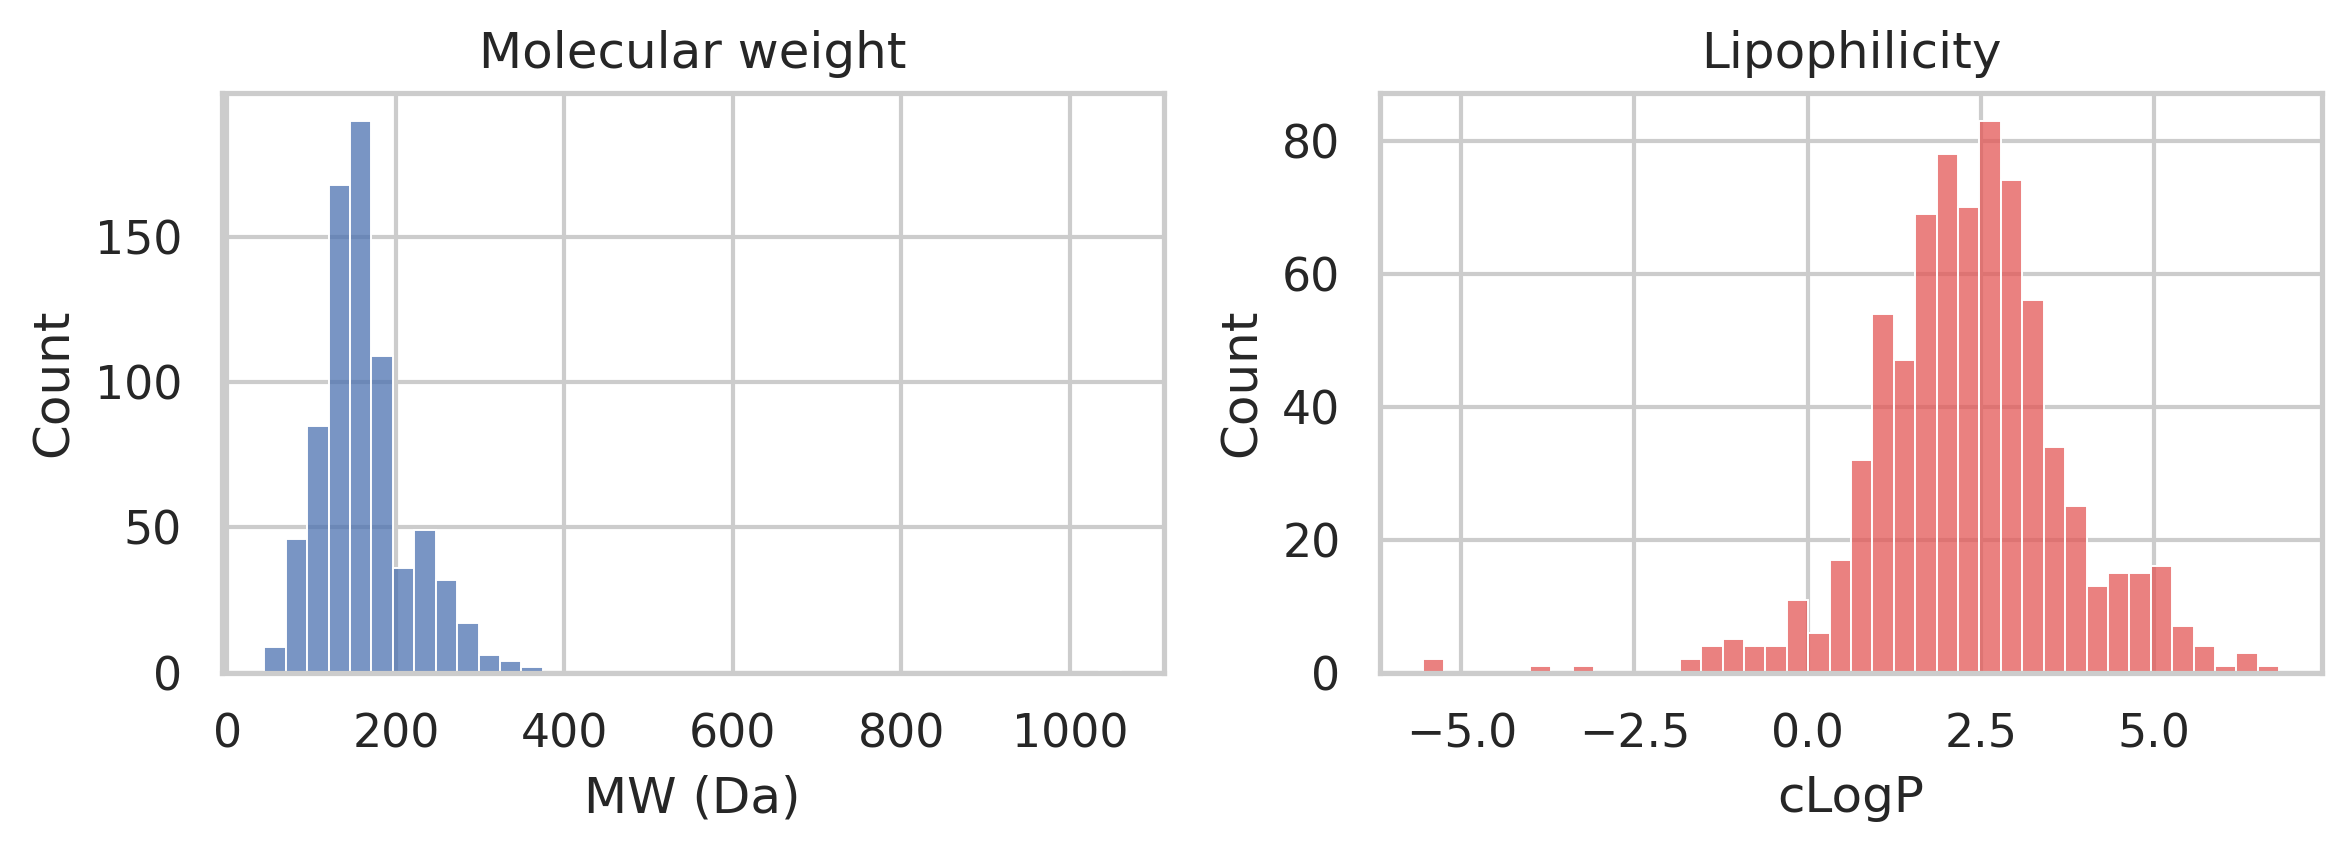

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
sns.histplot(desc["MW"].dropna(), bins=40, color="#4C72B0", ax=axes[0])
axes[0].set_title("Molecular weight")
axes[0].set_xlabel("MW (Da)")
sns.histplot(desc["LogP"].dropna(), bins=40, color="#E45756", ax=axes[1])
axes[1].set_title("Lipophilicity")
axes[1].set_xlabel("cLogP")
fig.tight_layout()
savefig(fig, "09_chemspace")
plt.show()


Odorants are, as expected, **small and lipophilic** — mostly < 300 Da with positive
LogP — consistent with volatile small molecules.

## 11. Sparsity of the receptor × molecule matrix

Only a tiny fraction of all possible (receptor, molecule) combinations have actually been
tested — worth knowing for anyone thinking of it as a matrix-completion problem.

In [17]:
R = df["Gene Name"].nunique()
M = df["SMILES"].nunique()
tested = df.drop_duplicates(["Gene Name", "SMILES"]).shape[0]
possible = R * M
print(f"receptors           : {R:,}")
print(f"molecules           : {M:,}")
print(f"possible pairs      : {possible:,}")
print(f"distinct pairs tested: {tested:,}")
print(f"matrix filled       : {tested / possible:.2%}")


receptors           : 563
molecules           : 771
possible pairs      : 434,073
distinct pairs tested: 45,530
matrix filled       : 10.49%


## 12. PCA of the chemical descriptors

Project the odorant chemical space onto its first two principal components. We use a
slightly broader, standardised descriptor set and colour each molecule by whether it is
**ever a confirmed ligand** (appears in at least one responsive pair) to see whether hits
occupy a distinct region of chemical space.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Expanded descriptor set for the PCA
def descriptors_full(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return pd.Series({k: np.nan for k in
                          ["MW", "LogP", "TPSA", "HBD", "HBA",
                           "RotB", "AromRings", "n_heavy"]})
    return pd.Series({
        "MW": Descriptors.MolWt(m),
        "LogP": Crippen.MolLogP(m),
        "TPSA": Descriptors.TPSA(m),
        "HBD": Descriptors.NumHDonors(m),
        "HBA": Descriptors.NumHAcceptors(m),
        "RotB": Descriptors.NumRotatableBonds(m),
        "AromRings": Descriptors.NumAromaticRings(m),
        "n_heavy": m.GetNumHeavyAtoms(),
    })

feat_cols = ["MW", "LogP", "TPSA", "HBD", "HBA", "RotB", "AromRings", "n_heavy"]
X = mols.join(mols["SMILES"].apply(descriptors_full)).dropna(subset=feat_cols)

# Per-molecule label: is this SMILES ever a confirmed ligand?
ever_hit = df.groupby("SMILES")["Responsive"].max()
X["ever_hit"] = X["SMILES"].map(ever_hit).fillna(0).astype(int)

Z = StandardScaler().fit_transform(X[feat_cols].values)
pca = PCA(n_components=2, random_state=0).fit(Z)
pcs = pca.transform(Z)
X["PC1"], X["PC2"] = pcs[:, 0], pcs[:, 1]
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3),
      "  (sum =", round(pca.explained_variance_ratio_[:2].sum(), 3), ")")


Explained variance ratio: [0.439 0.269]   (sum = 0.709 )


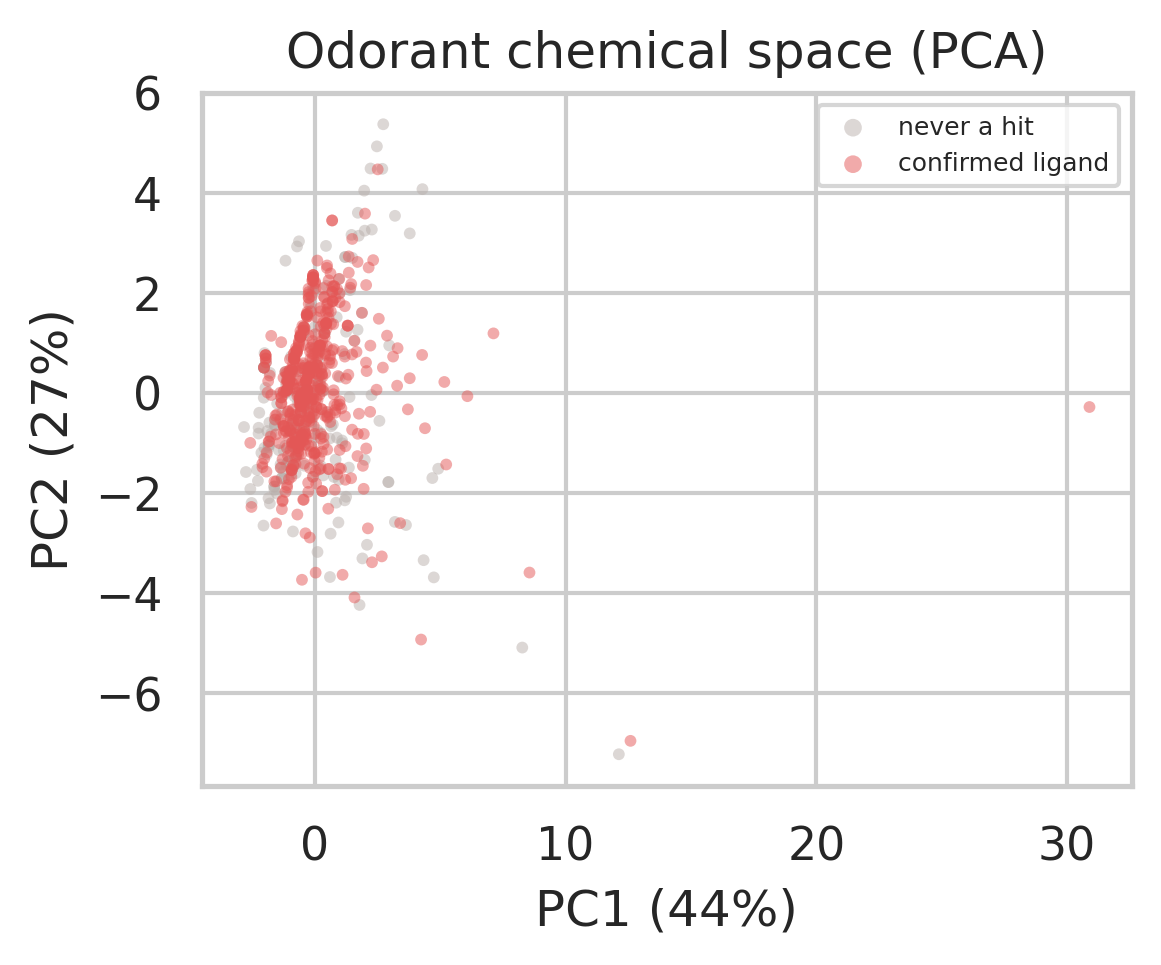

In [19]:
fig, ax = plt.subplots(figsize=FIGSIZE)
for label, color, name in [(0, "#BAB0AC", "never a hit"),
                           (1, "#E45756", "confirmed ligand")]:
    sub = X[X["ever_hit"] == label]
    ax.scatter(sub["PC1"], sub["PC2"], s=8, alpha=0.5, c=color, label=name,
               edgecolors="none")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
ax.set_title("Odorant chemical space (PCA)")
ax.legend(fontsize=6, markerscale=1.5, frameon=True)
savefig(fig, "10_pca_scatter")
plt.show()


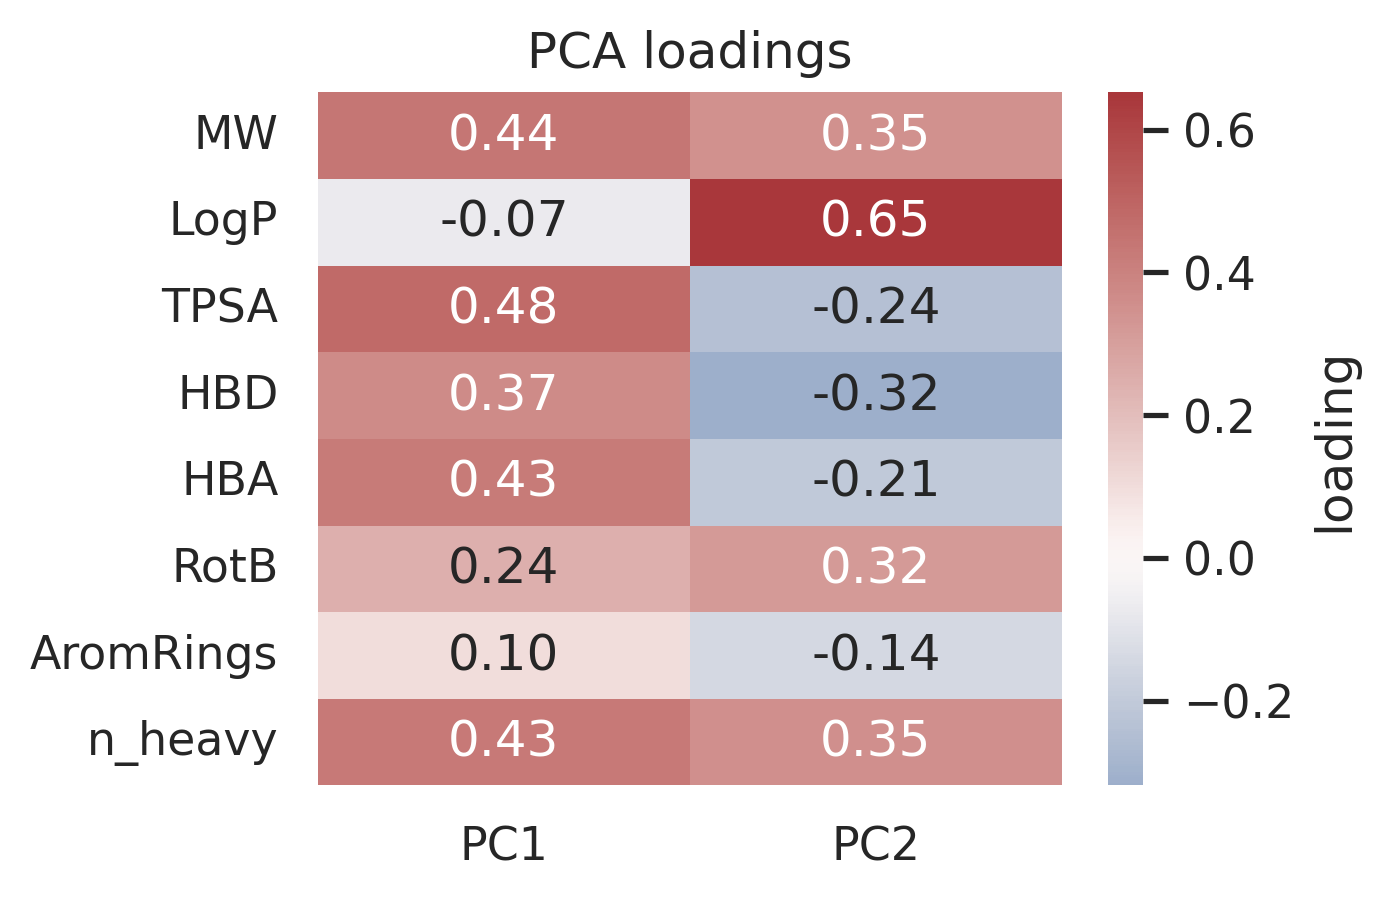

In [20]:
# Which descriptors drive each component
loadings = pd.DataFrame(pca.components_.T, index=feat_cols,
                        columns=["PC1", "PC2"])

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="vlag", center=0,
            cbar_kws={"label": "loading"}, ax=ax)
ax.set_title("PCA loadings")
savefig(fig, "11_pca_loadings")
plt.show()


**Reading it.** PC1 is essentially a **size / lipophilicity** axis (MW, heavy atoms,
LogP, rotatable bonds), while PC2 is driven by **polarity / H-bonding** (TPSA, HBA, HBD).
Confirmed ligands are spread throughout the same cloud as the untested/inactive molecules
rather than forming a separate island — i.e. activity is **not** trivially separable from
these bulk physicochemical descriptors alone, which is expected: selectivity is driven by
finer structural features (a Morgan/ECFP fingerprint would be the next step).

## 13. Summary of findings

- **~53k receptor–ligand pairs** covering **598 receptors** (UniProt) and **~770 unique
  molecules** across **16 species**, dominated by **human** and **mouse**.
- **Label is heavily imbalanced** — only **~6% positives** (responses). Modelling should
  use stratified splits, class weighting/resampling and PR-AUC-style metrics.
- **Coverage is very uneven:** a few receptors and a few odorants (e.g. common reference
  molecules) account for a large share of the experiments; many receptors have few tests.
- **Mostly wild-type** receptors, with a `Mutation` minority; `ec50` (dose-response) rows
  are the highest-confidence, highest-hit-rate subset.
- **Ligands are small, lipophilic odorants** (MW mostly < 300 Da, positive LogP), and the
  receptors are ~310 aa 7-TM GPCRs — both distributions look clean.
- The **receptor × molecule matrix is extremely sparse** (well under 1% filled), so this is
  a natural candidate for a chemogenomic / matrix-completion framing.

*All figures exported to `./figures/` as paired SVG + PNG.*
